# 02 — Descriptive Analyses

Analysis code for: *Test-Retest Reliability of a Pavlovian Go/No-Go Task with a Controllability Manipulation*

**Outputs:**
- Table 1: Demographic characteristics
- Table 2: Task appraisals
- Figure 2A: Trial-by-trial Go response probabilities
- Figure 2B: Group-median behavioural measures
- Figure 2C: Performance distribution across participants
- Table 3: Descriptive statistics (permutation tests)
- Figure 3A: ICC — behavioural measures
- Figure 3B: ICC — LPM regression coefficients
- Figure 4A: Go response rates by trial type
- Figure 4B: LPM fixed effects
- Figure 4C: GEE coefficients across exposures

> **Prerequisite:** Run `01_Screening.ipynb` first to generate `data/reject.csv`.

## 1 — Setup

In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
from itertools import combinations
from pandas import DataFrame, read_csv, concat
from tqdm import tqdm
from scipy.stats import chi2_contingency
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable
from pingouin import intraclass_corr

# Directories
ANALYSIS_DIR = os.getcwd()
DATA_DIR     = os.path.join(ANALYSIS_DIR, 'data')
RAW_DEMO_DIR = os.path.join(DATA_DIR, 'raw', 'demographic')
FIG_DIR      = os.path.join(ANALYSIS_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Aesthetics
labelcolor      = '#505050'
tickcolor       = '#606060'
axiscolor       = '#d3d3d3'
palette_robot   = ['#234f81', '#8e9cb8', '#bf8a82', '#812623']
palette_session = {1: '#234f81', 2: '#ababab'}
palette_3       = ['#234f81', '#6d7b96', '#ababab']
COLOR_CON       = '#3d6b9e'
COLOR_UNC       = '#a84340'
COLOR_DIFF      = '#505050'

sns.set_theme(style='ticks', context='notebook', font_scale=1.1)

# Analysis parameters
np.random.seed(47404)
n_iter   = 5000
sessions = [1, 2]
pairs    = list(combinations(sessions, 2))
conds    = ['controllable', 'uncontrollable']
robots   = ['gw', 'ngw', 'gal', 'ngal']
robot_labels = {'gw': 'GW', 'ngw': 'NGW', 'gal': 'GAL', 'ngal': 'NGAL'}

# Helper functions
def mad(x):
    return np.nanmedian(np.abs(x - np.nanmedian(x)))

def cohens_d(x, popmean=0):
    return np.abs(np.nanmedian(x) - popmean) / (mad(x) / 0.6745)

def resample(x):
    return np.random.choice(x, len(x), replace=True)

def bootstrap_ci(values, n_boot=5000, ci=95):
    boot = [np.median(np.random.choice(values, len(values), replace=True))
            for _ in range(n_boot)]
    return np.median(values), np.percentile(boot, (100-ci)/2), np.percentile(boot, 100-(100-ci)/2)

def permutation_test_vs_ref(vals, ref=0, n_iter=5000):
    vals = np.array(vals)
    obs  = np.nanmedian(vals) - ref
    d    = cohens_d(vals - ref)
    null = np.array([np.nanmedian(resample(vals)) - ref for _ in range(n_iter)])
    p    = np.mean(np.abs(null) >= np.abs(obs))
    return np.nanmedian(vals), d, p

def permutation_test_diff(vals, n_iter=5000):
    vals = np.array(vals)
    obs  = np.nanmedian(vals)
    d    = cohens_d(vals)
    null = np.array([np.nanmedian(resample(vals)) for _ in range(n_iter)])
    p    = np.mean(np.abs(null) >= np.abs(obs))
    return obs, d, p

def compute_icc(s1_vals, s2_vals):
    n  = min(len(s1_vals), len(s2_vals))
    df = pd.DataFrame({
        'subject': list(range(n)) * 2,
        'session': [1]*n + [2]*n,
        'value':   list(s1_vals[:n]) + list(s2_vals[:n])
    })
    try:
        icc = intraclass_corr(data=df, targets='subject', raters='session', ratings='value')
        row = icc[icc['Type'] == 'ICC3']
        r   = row['ICC'].values[0]
        ci  = row['CI95'].values[0]
        return float(r), float(ci[0]), float(ci[1])
    except:
        return np.nan, np.nan, np.nan

print('Setup complete.')

Setup complete.


## 2 — Table 1: Demographic Characteristics

In [2]:
# Load demographic data
dfs = []
for fname in sorted(os.listdir(RAW_DEMO_DIR)):
    if not fname.endswith('.csv'): continue
    df = read_csv(os.path.join(RAW_DEMO_DIR, fname))
    df['batch'] = fname
    dfs.append(df)

demo_raw = pd.concat(dfs, ignore_index=True)
demo_raw = demo_raw.rename(columns={
    'Participant id': 'subject', 'Age': 'age',
    'Sex': 'gender', 'Ethnicity simplified': 'ethnicity'})
demo_raw = demo_raw[demo_raw['Status'].isin(['APPROVED', 'AWAITING REVIEW'])].reset_index(drop=True)

reject = read_csv(os.path.join(DATA_DIR, 'reject.csv'))
demo   = demo_raw[demo_raw['subject'].isin(
             reject.query('reject == 0').subject)].reset_index(drop=True)
demo['age'] = demo['age'].astype(int)
N = len(demo)

def fmt(n, total):
    return f'{n} ({np.round(n/total*100, 1)}%)'

rows = []
rows.append({'Variable': 'Gender, N (%)', 'Value': ''})
for cat, n in demo['gender'].value_counts().items():
    rows.append({'Variable': f'  {cat}', 'Value': fmt(n, N)})
rows.append({'Variable': 'Age, years', 'Value': ''})
rows.append({'Variable': '  Mean (range)',
             'Value': f'{demo["age"].mean():.1f} ({int(demo["age"].min())}\u2013{int(demo["age"].max())})'})
rows.append({'Variable': 'Ethnicity, N (%)', 'Value': ''})
for cat, n in demo['ethnicity'].value_counts().items():
    rows.append({'Variable': f'  {cat}', 'Value': fmt(n, N)})

print(f'Table 1: Demographic Characteristics (N={N})')
print('=' * 50)
print(f'{"Variable":<35} {"N (%) or value"}')
print('-' * 50)
for _, row in DataFrame(rows).iterrows():
    if row['Value'] == '':
        print(row['Variable'])
    else:
        print(f'{row["Variable"]:<35} {row["Value"]}')
print('=' * 50)

Table 1: Demographic Characteristics (N=24)
Variable                            N (%) or value
--------------------------------------------------
Gender, N (%)
  Female                            12 (50.0%)
  Male                              12 (50.0%)
Age, years
  Mean (range)                      38.3 (25–56)
Ethnicity, N (%)
  White                             19 (79.2%)
  Black                             3 (12.5%)
  Asian                             2 (8.3%)


## 3 — Table 2: Task Appraisals

In [3]:
keep   = reject.query('reject==0')['subject'].values
deb_s1 = read_csv(os.path.join(DATA_DIR, 'debriefing_s1.csv'), skiprows=[1,2])
deb_s2 = read_csv(os.path.join(DATA_DIR, 'debriefing_s2.csv'), skiprows=[1,2])

deb_s1 = deb_s1[deb_s1['Status']=='IP Address'].reset_index(drop=True)
deb_s2 = deb_s2[deb_s2['Status']=='IP Address'].reset_index(drop=True)
deb_s1 = deb_s1[deb_s1['subject_ID'].isin(keep)].reset_index(drop=True)
deb_s2 = deb_s2[deb_s2['subject_ID'].isin(keep)].reset_index(drop=True)

rename = {'debriefing_1': 'difficulty', 'debriefing_2': 'fun',
          'debriefing_3': 'clarity',    'debriefing_4': 'strategy'}
deb_s1 = deb_s1.rename(columns=rename)
deb_s2 = deb_s2.rename(columns=rename)

difficulty_map = {'Very easy': 1, 'Somewhat easy': 2, 'Neither easy nor hard': 3,
                  'Somewhat hard': 4, 'Very hard': 5}
fun_map        = {'Very boring': 1, 'Somewhat boring': 2, 'Neither fun nor boring': 3,
                  'Somewhat fun': 4, 'Very fun': 5}
clarity_map    = {'Very confusing': 1, 'Somewhat confusing': 2,
                  'Neither clear nor confusing': 3, 'Somewhat clear': 4, 'Very clear': 5}

for deb in [deb_s1, deb_s2]:
    deb['difficulty_num'] = deb['difficulty'].map(difficulty_map)
    deb['fun_num']        = deb['fun'].map(fun_map)
    deb['clarity_num']    = deb['clarity'].map(clarity_map)

print(f'S1: {len(deb_s1)} | S2: {len(deb_s2)} participants')
print('\nTable 2: Task Appraisals — Mean (SD)')
print(f'{"":15} {"Session 1":15} {"Session 2":15}')
for col, label in [('difficulty_num','Difficulty'),('fun_num','Fun'),('clarity_num','Clarity')]:
    s1 = f'{deb_s1[col].mean():.1f} ({deb_s1[col].std():.1f})'
    s2 = f'{deb_s2[col].mean():.1f} ({deb_s2[col].std():.1f})'
    print(f'{label:15} {s1:15} {s2:15}')

S1: 24 | S2: 24 participants

Table 2: Task Appraisals — Mean (SD)
                Session 1       Session 2      
Difficulty      3.3 (1.1)       2.8 (1.0)      
Fun             3.8 (1.1)       3.8 (1.1)      
Clarity         5.0 (0.2)       5.0 (0.2)      


## 4 — Load Behavioural Data

In [4]:
data = read_csv(os.path.join(DATA_DIR, 'pgng.csv'))
data = data[data.subject.isin(reject.query('reject==0').subject)].reset_index(drop=True)

# Derived variables
data['congruence']  = data['robot_type'].replace({'gw':'c','ngal':'c','ngw':'i','gal':'i'})
data['prev_sham']   = data.groupby(['subject','session','stimulus'])['sham'].transform(lambda x: x.shift(1))
data.loc[data['exposure']==1, 'prev_sham'] = np.nan
subj_map            = {s: i+1 for i, s in enumerate(sorted(data['subject'].unique()))}
data['subject_id']  = data['subject'].map(subj_map)
data['valence_bin'] = (data['valence']=='win').astype(int)
data['action_bin']  = (data['action']=='go').astype(int)

print(f'N = {data.subject.nunique()} participants')
print(data.groupby('session').subject.nunique())

N = 24 participants
session
1    24
2    24
Name: subject, dtype: int64


## 5 — Figure 2A: Trial-by-trial Go Response Probabilities

In [5]:
# Summary data
print('Mean Go rates at exposure 1 and 15 (by session x condition x trial type):')
for sess in sessions:
    for cond in conds:
        sub = data[(data['session']==sess)&(data['controllability']==cond)]
        for exp in [1, 15]:
            gb = sub[sub['exposure']==exp].groupby('robot_type')['choice'].mean()
            print(f'  S{sess} {cond[:3]} exp={exp}: ' +
                  ' | '.join([f'{r.upper()}={gb.get(r,np.nan):.2f}' for r in robots]))

Mean Go rates at exposure 1 and 15 (by session x condition x trial type):
  S1 con exp=1: GW=0.90 | NGW=0.88 | GAL=0.61 | NGAL=0.61
  S1 con exp=15: GW=0.93 | NGW=0.50 | GAL=0.64 | NGAL=0.22
  S1 unc exp=1: GW=0.89 | NGW=0.93 | GAL=0.61 | NGAL=0.64
  S1 unc exp=15: GW=0.76 | NGW=0.86 | GAL=0.43 | NGAL=0.46
  S2 con exp=1: GW=0.81 | NGW=0.90 | GAL=0.51 | NGAL=0.64
  S2 con exp=15: GW=0.83 | NGW=0.49 | GAL=0.56 | NGAL=0.26
  S2 unc exp=1: GW=0.78 | NGW=0.83 | GAL=0.44 | NGAL=0.53
  S2 unc exp=15: GW=0.74 | NGW=0.68 | GAL=0.38 | NGAL=0.43


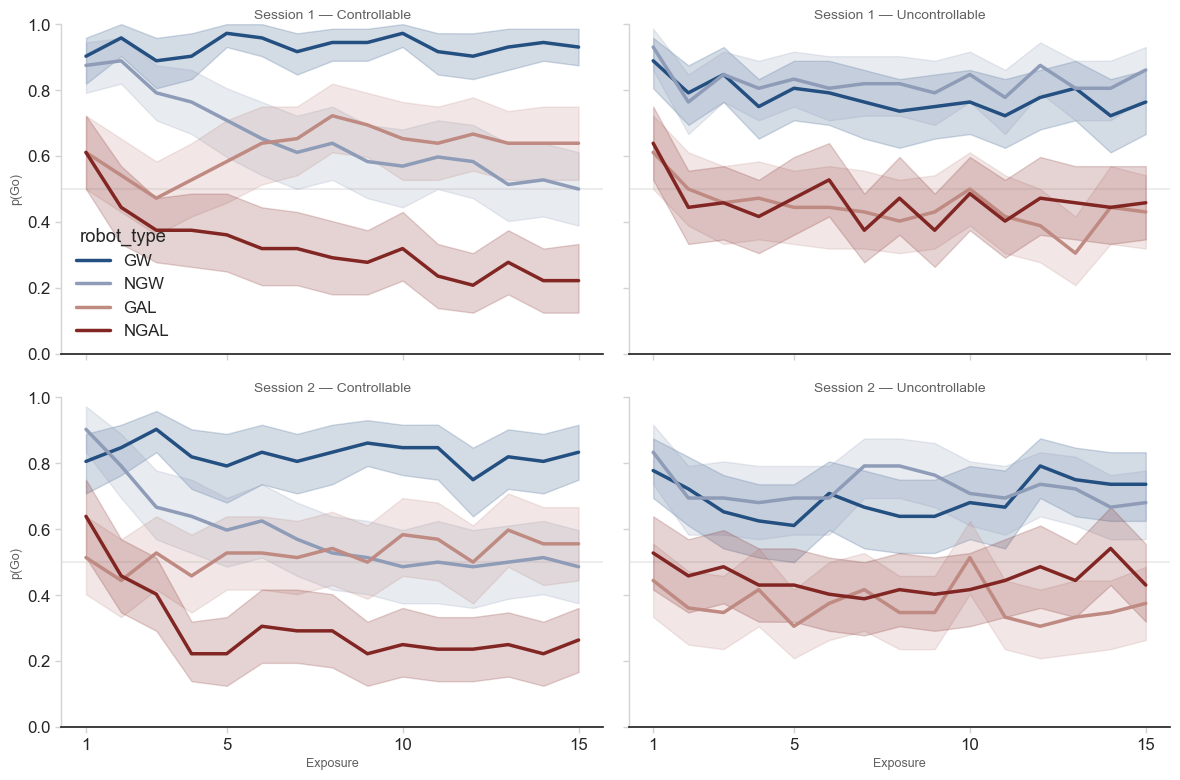

Saved fig02A


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True, sharex=True)
fig.patch.set_facecolor('white')

for r, sess in enumerate(sessions):
    for c, cond in enumerate(conds):
        ax  = axes[r, c]
        sub = data[(data['session']==sess)&(data['controllability']==cond)]
        sns.lineplot(data=sub, x='exposure', y='choice', hue='robot_type',
                     hue_order=robots, palette=palette_robot,
                     lw=2.5, errorbar=('ci',95), legend=(r==0 and c==0), ax=ax)
        ax.axhline(0.5, color='k', alpha=0.08, zorder=-1)
        ax.set_title(f'Session {sess} — {cond.capitalize()}',
                     color=tickcolor, fontsize=10, pad=4)
        ax.set_xlabel('Exposure', color=tickcolor, fontsize=9)
        ax.set_xticks([1, 5, 10, 15])
        ax.set(ylim=(0, 1))
        ax.set_yticks(np.linspace(0, 1, 6))
        ax.spines['left'].set(linewidth=1, color=axiscolor)
        ax.tick_params(bottom=True, left=True, color=axiscolor, length=4, width=1)
        sns.despine(ax=ax, left=False, right=True, top=True, bottom=False)
        if c == 0:
            ax.set_ylabel('p(Go)', color=tickcolor, fontsize=9)
        if r == 0 and c == 0:
            leg = ax.get_legend()
            if leg:
                for t, label in zip(leg.get_texts(), [r.upper() for r in robots]):
                    t.set_text(label)
                leg.set_frame_on(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig02A_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig02A_learning_curves.pdf'), bbox_inches='tight')
plt.show()
print('Saved fig02A')

## 6 — Table 3: Descriptive Statistics (Permutation Tests)

Three sets of comparisons (5,000 permutations each):
1. Within-session vs reference (0.5 for accuracy; 0 for all other measures)
2. Between-condition (controllable vs uncontrollable) within each session
3. Between-session (S1 vs S2) within each condition

In [7]:
np.random.seed(47404)

def get_bias(data, cond, measure):
    sub = data[data['controllability']==cond]
    if measure == 'accuracy':
        return sub.pivot_table('accuracy','subject','session')
    elif measure == 'go_bias':
        p = sub.pivot_table('accuracy',['session','subject'],'action')
        return (p['go']-p['no-go']).unstack(level=0)
    elif measure == 'pav_bias':
        p = sub.pivot_table('accuracy',['session','subject'],'congruence')
        return (p['c']-p['i']).unstack(level=0)
    elif measure == 'approach':
        p = sub.pivot_table('accuracy',['session','subject'],'robot_type')
        return (p['gw']-p['ngw']).unstack(level=0)
    elif measure == 'avoidance':
        p = sub.pivot_table('accuracy',['session','subject'],'robot_type')
        return (p['ngal']-p['gal']).unstack(level=0)

measures_table = [
    ('accuracy',  'Overall accuracy',   0.5),
    ('go_bias',   'Go bias',            0.0),
    ('pav_bias',  'Pavlovian bias',     0.0),
    ('approach',  'Approach bias',      0.0),
    ('avoidance', 'Avoidance bias',     0.0),
]

for mkey, mlabel, ref in measures_table:
    print(f'\n{"="*60}')
    print(f'{mlabel}')
    print(f'{"="*60}')
    for cond in conds:
        pivot = get_bias(data, cond, mkey)
        print(f'\n  [{cond}]')
        print(f'  Within-session (vs ref={ref}):')
        for sess in sessions:
            if sess not in pivot.columns: continue
            vals = pivot[sess].dropna().values
            mdn, d, p = permutation_test_vs_ref(vals, ref=ref)
            sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'
            print(f'    S{sess}: Mdn={mdn:.3f}, d={d:.3f}, p={p:.3f} {sig}')
        # Between-condition
    print(f'\n  [Controllability effect (Con - Uncon)]:')
    for sess in sessions:
        p_con = get_bias(data, 'controllable', mkey)
        p_unc = get_bias(data, 'uncontrollable', mkey)
        if sess not in p_con.columns or sess not in p_unc.columns: continue
        common = p_con[sess].dropna().index.intersection(p_unc[sess].dropna().index)
        diff = p_con[sess].loc[common].values - p_unc[sess].loc[common].values
        mdn, d, p = permutation_test_diff(diff)
        sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'
        print(f'    S{sess}: Mdn={mdn:.3f}, d={d:.3f}, p={p:.3f} {sig}')
    # Between-session
    print(f'\n  [Between-session (S1 - S2)]:')
    for cond in conds:
        pivot = get_bias(data, cond, mkey).dropna()
        if 1 not in pivot.columns or 2 not in pivot.columns: continue
        diff = pivot[1].values - pivot[2].values
        mdn, d, p = permutation_test_diff(diff)
        sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'
        print(f'    {cond}: Mdn={mdn:.3f}, d={d:.3f}, p={p:.3f} {sig}')


Overall accuracy

  [controllable]
  Within-session (vs ref=0.5):
    S1: Mdn=0.636, d=0.787, p=0.517 ns
    S2: Mdn=0.567, d=0.704, p=0.527 ns

  [uncontrollable]
  Within-session (vs ref=0.5):
    S1: Mdn=0.500, d=0.000, p=1.000 ns
    S2: Mdn=0.483, d=0.311, p=0.753 ns

  [Controllability effect (Con - Uncon)]:
    S1: Mdn=0.119, d=0.691, p=0.537 ns
    S2: Mdn=0.089, d=0.799, p=0.542 ns

  [Between-session (S1 - S2)]:
    controllable: Mdn=0.014, d=0.337, p=0.549 ns
    uncontrollable: Mdn=0.031, d=0.571, p=0.528 ns

Go bias

  [controllable]
  Within-session (vs ref=0.0):
    S1: Mdn=0.267, d=1.116, p=0.524 ns
    S2: Mdn=0.178, d=0.771, p=0.517 ns

  [uncontrollable]
  Within-session (vs ref=0.0):
    S1: Mdn=0.367, d=1.855, p=0.539 ns
    S2: Mdn=0.172, d=0.653, p=0.524 ns

  [Controllability effect (Con - Uncon)]:
    S1: Mdn=-0.022, d=0.087, p=0.714 ns
    S2: Mdn=0.017, d=0.106, p=0.633 ns

  [Between-session (S1 - S2)]:
    controllable: Mdn=0.083, d=0.361, p=0.545 ns
    u

In [8]:
# Feedback sensitivity (controllable only)
np.random.seed(47404)
print('Feedback sensitivity (controllable condition only)')
sub   = data[data['controllability']=='controllable']
sub2  = sub[sub['prev_sham'].isin([0.0, 1.0])]
pivot = sub2.pivot_table('accuracy',['session','subject'],'prev_sham')
bias  = (pivot[0.0]-pivot[1.0]).unstack(level=0)
print('  Within-session:')
for sess in sessions:
    if sess not in bias.columns: continue
    vals = bias[sess].dropna().values
    mdn, d, p = permutation_test_vs_ref(vals, ref=0)
    sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'
    print(f'    S{sess}: Mdn={mdn:.3f}, d={d:.3f}, p={p:.3f} {sig}')
print('  Between-session:')
pivot2 = bias.dropna()
if 1 in pivot2.columns and 2 in pivot2.columns:
    diff = pivot2[1].values - pivot2[2].values
    mdn, d, p = permutation_test_diff(diff)
    sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'
    print(f'    S1-S2: Mdn={mdn:.3f}, d={d:.3f}, p={p:.3f} {sig}')

Feedback sensitivity (controllable condition only)
  Within-session:
    S1: Mdn=0.101, d=0.877, p=0.546 ns
    S2: Mdn=0.091, d=1.077, p=0.519 ns
  Between-session:
    S1-S2: Mdn=0.005, d=0.054, p=0.833 ns


In [9]:
# Performance distribution (chi-squared)
print('Performance distribution shifts (chi-squared):')
gb = data.groupby(['subject','session','controllability','robot_type'])['accuracy'].mean().reset_index()
gb['score'] = np.digitize(gb['accuracy'], [0.6, 0.9])
for cond in conds:
    print(f'\n  [{cond}]')
    for robot in robots:
        sub   = gb[(gb['controllability']==cond)&(gb['robot_type']==robot)]
        table = pd.crosstab(sub['score'], sub['session'])
        if table.shape == (3, 2):
            chi2, p, dof, _ = chi2_contingency(table)
            sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'
            print(f'    {robot.upper()}: chi2({dof})={chi2:.2f}, p={p:.3f} {sig}')

Performance distribution shifts (chi-squared):

  [controllable]
    GW: chi2(2)=6.78, p=0.034 *
    GAL: chi2(2)=0.43, p=0.807 ns
    NGAL: chi2(2)=1.13, p=0.567 ns

  [uncontrollable]
    GW: chi2(2)=1.26, p=0.534 ns
    NGAL: chi2(2)=2.66, p=0.265 ns


## 7 — Figure 2B: Group-Median Behavioural Measures

In [10]:
# Summary
print('Group medians by session x condition:')
for mkey, mlabel, ref in measures_table:
    print(f'\n  {mlabel}:')
    for cond in conds:
        pivot = get_bias(data, cond, mkey)
        for sess in sessions:
            if sess not in pivot.columns: continue
            mdn = np.nanmedian(pivot[sess].dropna().values)
            print(f'    S{sess} {cond[:3]}: Mdn={mdn:.3f}')

Group medians by session x condition:

  Overall accuracy:
    S1 con: Mdn=0.636
    S2 con: Mdn=0.567
    S1 unc: Mdn=0.500
    S2 unc: Mdn=0.483

  Go bias:
    S1 con: Mdn=0.267
    S2 con: Mdn=0.178
    S1 unc: Mdn=0.367
    S2 unc: Mdn=0.172

  Pavlovian bias:
    S1 con: Mdn=0.244
    S2 con: Mdn=0.211
    S1 unc: Mdn=0.283
    S2 unc: Mdn=0.228

  Approach bias:
    S1 con: Mdn=0.567
    S2 con: Mdn=0.400
    S1 unc: Mdn=0.667
    S2 unc: Mdn=0.511

  Avoidance bias:
    S1 con: Mdn=-0.022
    S2 con: Mdn=0.133
    S1 unc: Mdn=-0.089
    S2 unc: Mdn=0.167


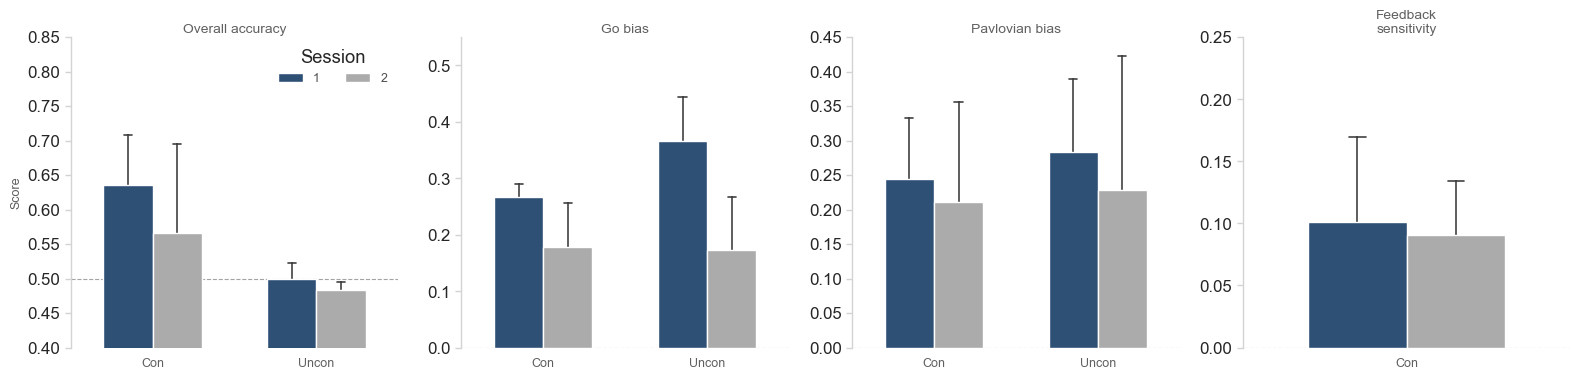

Saved fig02B


In [11]:
np.random.seed(47404)

measures_B = [
    ('accuracy', 'Overall accuracy', 0.5),
    ('go_bias',  'Go bias',          0.0),
    ('pav_bias', 'Pavlovian bias',   0.0),
    ('feedback', 'Feedback\nsensitivity', 0.0),
]
ylim_map = {
    'accuracy': (0.40, 0.85),
    'go_bias':  (0.00, 0.55),
    'pav_bias': (0.00, 0.45),
    'feedback': (0.00, 0.25),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor('white')

for col, (key, title, ref) in enumerate(measures_B):
    ax = axes[col]
    records = []
    for cond in conds:
        if key == 'feedback' and cond == 'uncontrollable': continue
        sub = data[data['controllability']==cond]
        if key == 'accuracy':
            gb = sub.groupby(['subject','session'])['accuracy'].mean().reset_index()
            gb = gb.rename(columns={'accuracy':'value'})
        elif key == 'go_bias':
            go  = sub[sub['action']=='go'].groupby(['subject','session'])['accuracy'].mean()
            ngo = sub[sub['action']=='no-go'].groupby(['subject','session'])['accuracy'].mean()
            gb  = (go-ngo).reset_index(); gb.columns=['subject','session','value']
        elif key == 'pav_bias':
            con = sub[sub['congruence']=='c'].groupby(['subject','session'])['accuracy'].mean()
            inc = sub[sub['congruence']=='i'].groupby(['subject','session'])['accuracy'].mean()
            gb  = (con-inc).reset_index(); gb.columns=['subject','session','value']
        elif key == 'feedback':
            sub2 = sub[sub['prev_sham'].isin([0.0,1.0])]
            ver  = sub2[sub2['prev_sham']==0.0].groupby(['subject','session'])['accuracy'].mean()
            sha  = sub2[sub2['prev_sham']==1.0].groupby(['subject','session'])['accuracy'].mean()
            gb   = (ver-sha).reset_index(); gb.columns=['subject','session','value']
        gb['controllability'] = cond
        records.append(gb)

    gb_all = concat(records, ignore_index=True)
    order  = conds if key != 'feedback' else ['controllable']

    sns.barplot(x='controllability', y='value', hue='session',
                data=gb_all, order=order, hue_order=sessions,
                palette=palette_session, estimator=np.nanmedian,
                errorbar=('ci',95), width=0.6,
                err_kws={'linewidth':1.2}, capsize=0.1, zorder=5, ax=ax)
    ax.set_ylim(ylim_map[key])
    ax.axhline(ref, color='k', lw=0.8, ls='--', alpha=0.4)
    ax.set_title(title, color=tickcolor, fontsize=10, pad=3)
    ax.set_xlabel('')
    ticks = ['Con','Uncon'] if key != 'feedback' else ['Con']
    ax.set_xticks(range(len(ticks)))
    ax.set_xticklabels(ticks, color=tickcolor, fontsize=9)
    ax.spines['left'].set(linewidth=1, color=axiscolor)
    ax.tick_params(bottom=False, left=True, color=axiscolor, length=4, width=1)
    sns.despine(ax=ax, left=False, right=True, top=True, bottom=True)
    if col == 0:
        ax.set_ylabel('Score', color=tickcolor, fontsize=9)
        ax.legend(title='Session', frameon=False, fontsize=9, labelcolor=labelcolor,
                  loc='upper right', ncol=2)
    else:
        if ax.get_legend(): ax.get_legend().remove()
        ax.set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig02B_performance.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig02B_performance.pdf'), bbox_inches='tight')
plt.show()
print('Saved fig02B')

## 8 — Figure 2C: Performance Distribution

In [12]:
# Summary
gb = data.groupby(['subject','session','controllability','robot_type'])['accuracy'].mean().reset_index()
gb['score'] = np.digitize(gb['accuracy'], [0.6, 0.9])
score_labels = {0: '<60%', 1: '60-90%', 2: '>=90%'}
print('Performance band proportions (% of participants):')
for cond in conds:
    print(f'\n  [{cond}]')
    for robot in robots:
        sub = gb[(gb['controllability']==cond)&(gb['robot_type']==robot)]
        for sess in sessions:
            s   = sub[sub['session']==sess]
            tot = len(s)
            bands = [f"{score_labels[sc]}: {(s['score']==sc).sum()/tot*100:.0f}%"
                     for sc in [0,1,2]]
            print(f'    {robot.upper()} S{sess}: {" | ".join(bands)}')

Performance band proportions (% of participants):

  [controllable]
    GW S1: <60%: 0% | 60-90%: 29% | >=90%: 71%
    GW S2: <60%: 12% | 60-90%: 50% | >=90%: 38%
    NGW S1: <60%: 75% | 60-90%: 25% | >=90%: 0%
    NGW S2: <60%: 67% | 60-90%: 33% | >=90%: 0%
    GAL S1: <60%: 42% | 60-90%: 46% | >=90%: 12%
    GAL S2: <60%: 50% | 60-90%: 42% | >=90%: 8%
    NGAL S1: <60%: 29% | 60-90%: 67% | >=90%: 4%
    NGAL S2: <60%: 29% | 60-90%: 58% | >=90%: 12%

  [uncontrollable]
    GW S1: <60%: 17% | 60-90%: 54% | >=90%: 29%
    GW S2: <60%: 25% | 60-90%: 58% | >=90%: 17%
    NGW S1: <60%: 96% | 60-90%: 4% | >=90%: 0%
    NGW S2: <60%: 92% | 60-90%: 8% | >=90%: 0%
    GAL S1: <60%: 67% | 60-90%: 33% | >=90%: 0%
    GAL S2: <60%: 79% | 60-90%: 21% | >=90%: 0%
    NGAL S1: <60%: 71% | 60-90%: 17% | >=90%: 12%
    NGAL S2: <60%: 54% | 60-90%: 38% | >=90%: 8%


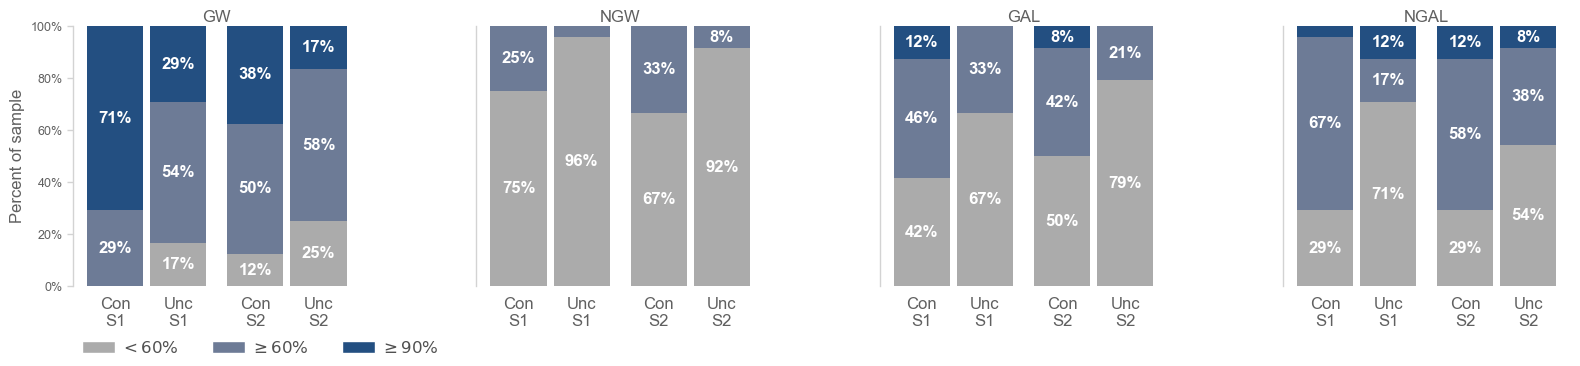

Saved fig02C


In [25]:
gb2   = gb.groupby(['session','controllability','robot_type','score']).size().reset_index(name='count')
total = gb.groupby(['session','controllability','robot_type']).size().reset_index(name='total')
gb2   = gb2.merge(total, on=['session','controllability','robot_type'])
gb2['prop']    = gb2['count'] / gb2['total']
gb2['cumprop'] = gb2.groupby(['session','controllability','robot_type'])['prop'].cumsum()

x_positions = {'s1_con':0, 's1_unc':0.45, 's2_con':1.0, 's2_unc':1.45}
x_labels    = ['Con\nS1','Unc\nS1','Con\nS2','Unc\nS2']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor('white')

for col, robot in enumerate(robots):
    ax = axes[col]
    for score, color in zip(sorted(gb2['score'].unique())[::-1], palette_3):
        for k, (sess, cond) in enumerate([(1,'controllable'),(1,'uncontrollable'),
                                           (2,'controllable'),(2,'uncontrollable')]):
            q = gb2[(gb2['robot_type']==robot)&(gb2['score']==score)&
                    (gb2['session']==sess)&(gb2['controllability']==cond)]
            if len(q)==0: continue
            xpos   = list(x_positions.values())[k]
            height = q['cumprop'].values[0]
            prop   = q['prop'].values[0]
            ax.bar(xpos, height, width=0.40, color=color, linewidth=0, zorder=3)
            if prop > 0.08:
                ax.text(xpos, height-prop/2, f'{prop*100:.0f}%',
                        ha='center', va='center', fontsize=12, color='white', fontweight='bold')
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(x_labels, color=tickcolor, fontsize=12)
    ax.set(xlim=(-0.3,1.75), ylim=(0,1))
    ax.set_title(robot.upper(), color=tickcolor, fontsize=12, pad=3)
    ax.spines['left'].set(linewidth=1, color=axiscolor)
    ax.tick_params(bottom=False, left=True, color=axiscolor, length=4, width=1)
    sns.despine(ax=ax, left=False, right=True, top=True, bottom=True)
    if col == 0:
        ax.set_yticks(np.linspace(0,1,6))
        ax.set_yticklabels(['%0.0f%%'%p for p in np.linspace(0,100,6)], color=tickcolor, fontsize=9)
        ax.set_ylabel('Percent of sample', color=tickcolor, fontsize=12)
        for sc, co in zip([r'$<60\%$',r'$\geq60\%$',r'$\geq90\%$'], palette_3[::-1]):
            ax.bar(0,0,color=co,label=sc)
        ax.legend(frameon=False, fontsize=12, ncol=3, loc='lower left',
                  bbox_to_anchor=(0, -0.3),
                  labelcolor=labelcolor, borderpad=0, handletextpad=0.3)
    else:
        ax.set_yticks([])
        ax.set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig02C_distribution.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig02C_distribution.pdf'), bbox_inches='tight')
plt.show()
print('Saved fig02C')

## 9 — Compute LPM and GEE for Figure 3

In [53]:
# Group-level LPM
lpm_group = []
for (sess, cond), grp in data.groupby(['session','controllability']):
    grp2 = grp.copy()
    grp2['interaction'] = grp2['valence_bin'] * grp2['action_bin']
    X = sm.add_constant(grp2[['valence_bin','action_bin','interaction']])
    try:
        model = sm.OLS(grp2['choice'], X).fit()
        ci    = model.conf_int()
        lpm_group.append({
            'session':sess, 'controllability':cond,
            'valence':     model.params['valence_bin'],
            'valence_lb':  ci.loc['valence_bin',0],
            'valence_ub':  ci.loc['valence_bin',1],
            'action':      model.params['action_bin'],
            'action_lb':   ci.loc['action_bin',0],
            'action_ub':   ci.loc['action_bin',1],
            'interaction': model.params['interaction'],
            'interaction_lb': ci.loc['interaction',0],
            'interaction_ub': ci.loc['interaction',1],
        })
    except Exception as e:
        print(f'LPM failed: {e}')

lpm_group_df = pd.DataFrame(lpm_group)
print('LPM group-level fixed effects:')
print(lpm_group_df[['session','controllability','valence','action','interaction']].round(3).to_string(index=False))

LPM group-level fixed effects:
 session controllability  valence  action  interaction
       1    controllable    0.330   0.297       -0.019
       1  uncontrollable    0.366  -0.015       -0.032
       2    controllable    0.286   0.227        0.013
       2  uncontrollable    0.276  -0.076        0.046


In [54]:
# GEE per exposure
gee_results = []
for (sess, cond, exp), grp in data.groupby(['session','controllability','exposure']):
    if len(grp) < 10: continue
    try:
        model  = GEE.from_formula('choice ~ valence_bin + action_bin',
                                  groups='subject_id', data=grp,
                                  family=Binomial(), cov_struct=Exchangeable())
        result = model.fit()
        ci     = result.conf_int()
        gee_results.append({
            'session':sess, 'controllability':cond, 'exposure':exp,
            'action_coef':  result.params['action_bin'],
            'action_lb':    ci.loc['action_bin',0],
            'action_ub':    ci.loc['action_bin',1],
            'valence_coef': result.params['valence_bin'],
            'valence_lb':   ci.loc['valence_bin',0],
            'valence_ub':   ci.loc['valence_bin',1],
        })
    except: pass

gee_df = pd.DataFrame(gee_results)
print(f'GEE completed: {len(gee_df)} rows')
print('\nMean GEE coefficients by condition:')
print(gee_df.groupby(['session','controllability'])[['action_coef','valence_coef']].mean().round(3))

GEE completed: 60 rows

Mean GEE coefficients by condition:
                         action_coef  valence_coef
session controllability                           
1       controllable           1.488         1.703
        uncontrollable        -0.158         1.619
2       controllable           1.069         1.361
        uncontrollable        -0.239         1.271


## 10 — Figure 3A: Go Response Rates by Trial Type

In [55]:
# Summary
print('Mean Go rates by session x condition x trial type:')
for sess in sessions:
    for cond in conds:
        sub = data[(data['session']==sess)&(data['controllability']==cond)]
        gb  = sub.groupby('robot_type')['choice'].mean()
        print(f'  S{sess} {cond[:3]}: ' + ' | '.join([f'{r.upper()}={gb.get(r,np.nan):.2f}' for r in robots]))

Mean Go rates by session x condition x trial type:
  S1 con: GW=0.93 | NGW=0.65 | GAL=0.62 | NGAL=0.32
  S1 unc: GW=0.78 | NGW=0.83 | GAL=0.45 | NGAL=0.46
  S2 con: GW=0.83 | NGW=0.59 | GAL=0.53 | NGAL=0.30
  S2 unc: GW=0.69 | NGW=0.72 | GAL=0.37 | NGAL=0.45


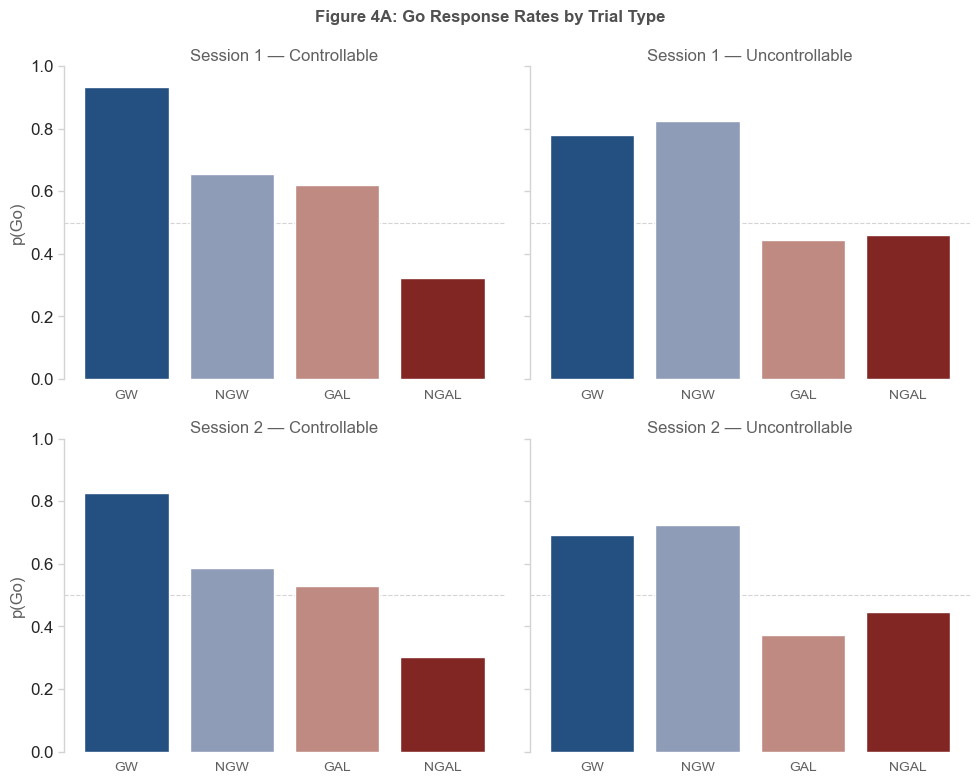

Saved fig04A


In [58]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
fig.patch.set_facecolor('white')

for r, sess in enumerate(sessions):
    for c, cond in enumerate(conds):
        ax  = axes[r, c]
        sub = data[(data['session']==sess)&(data['controllability']==cond)]
        gb  = sub.groupby('robot_type')['choice'].mean()
        vals = [gb.get(robot, 0) for robot in robots]
        ax.bar(range(4), vals, color=palette_robot, zorder=3)
        ax.axhline(0.5, color=axiscolor, lw=0.8, ls='--')
        ax.set_xticks(range(4))
        ax.set_xticklabels([robot_labels[robot] for robot in robots], color=tickcolor, fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_yticks(np.linspace(0,1,6))
        ax.set_title(f'Session {sess} — {cond.capitalize()}', color=tickcolor, fontsize=12, pad=4)
        ax.spines['left'].set(linewidth=1, color=axiscolor)
        ax.tick_params(bottom=False, left=True, color=axiscolor, length=4, width=1)
        sns.despine(ax=ax, left=False, right=True, top=True, bottom=True)
        if c == 0:
            ax.set_ylabel('p(Go)', color=tickcolor, fontsize=12)
        else:
            ax.set_yticklabels([f'{v:.1f}' for v in np.linspace(0,1,6)], color=tickcolor, fontsize=12)

plt.suptitle('Figure 3A: Go Response Rates by Trial Type', color=labelcolor, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig03A_go_rates.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig03A_go_rates.pdf'), bbox_inches='tight')
plt.show()
print('Saved fig03A')

## 11 — Figure 3B: LPM Fixed Effects

In [63]:
# Summary
print('LPM coefficients (group-level):')
for _, row in lpm_group_df.iterrows():
    print(f'  S{int(row["session"])} {row["controllability"][:3]}: '
          f'valence={row["valence"]:.3f}, action={row["action"]:.3f}, interaction={row["interaction"]:.3f}')

LPM coefficients (group-level):
  S1 con: valence=0.330, action=0.297, interaction=-0.019
  S1 unc: valence=0.366, action=-0.015, interaction=-0.032
  S2 con: valence=0.286, action=0.227, interaction=0.013
  S2 unc: valence=0.276, action=-0.076, interaction=0.046


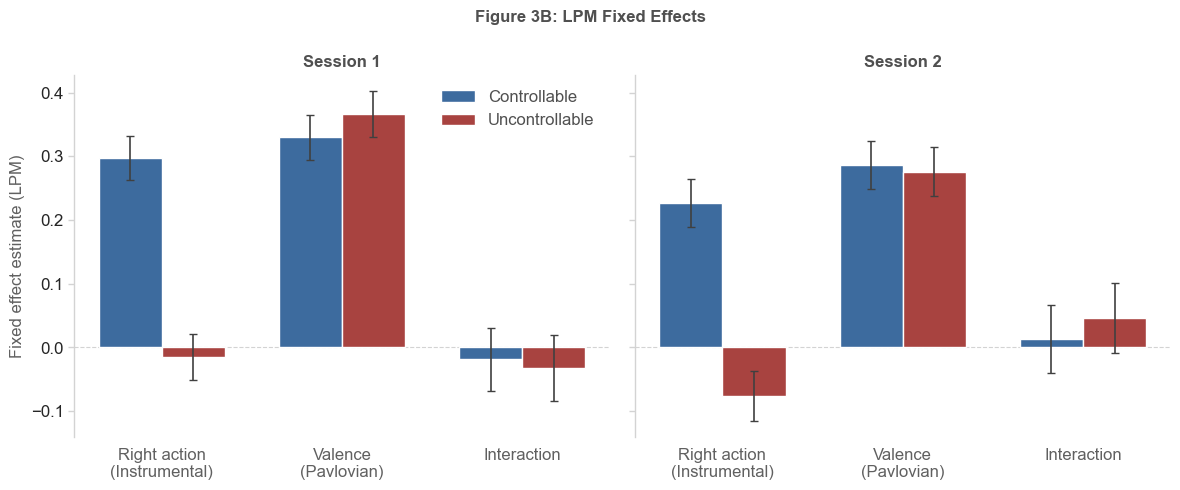

Saved fig03B


In [66]:
from statsmodels.formula.api import mixedlm

terms  = ['action_bin', 'valence_bin', 'action_bin:valence_bin']
labels = ['Right action\n(Instrumental)', 'Valence\n(Pavlovian)', 'Interaction']

results = []
for session in sessions:
    for cond in conds:
        sub = data[(data['session']==session)&(data['controllability']==cond)].copy()
        try:
            model  = mixedlm('choice ~ action_bin * valence_bin', sub, groups=sub['subject'])
            result = model.fit(reml=False)
            for term, label in zip(terms, labels):
                results.append({
                    'session':   session,
                    'condition': cond,
                    'term':      label,
                    'coef':      result.params[term],
                    'se':        result.bse[term],
                })
        except Exception as e:
            print(f'Error: session {session}, {cond}: {e}')

df_lpm = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.patch.set_facecolor('white')
bar_width = 0.35
x = np.arange(len(labels))

for col, session in enumerate(sessions):
    ax  = axes[col]
    sub = df_lpm[df_lpm['session']==session]
    for i, (cond, color) in enumerate(zip(conds, [COLOR_CON, COLOR_UNC])):
        grp    = sub[sub['condition']==cond].set_index('term').loc[labels]
        offset = (i - 0.5) * bar_width
        ax.bar(x+offset, grp['coef'].values, width=bar_width, color=color,
               label=cond.capitalize(), zorder=3)
        ax.errorbar(x+offset, grp['coef'].values,
                    yerr=1.96*grp['se'].values,
                    fmt='none', color='#404040', linewidth=1.2, capsize=3, zorder=4)
    ax.axhline(0, color=axiscolor, lw=0.8, ls='--')
    ax.set_title(f'Session {session}', color=labelcolor, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=tickcolor, fontsize=12)
    ax.tick_params(color=axiscolor, length=4, width=1, bottom=False)
    ax.spines['left'].set(linewidth=1, color=axiscolor)
    sns.despine(ax=ax, left=False, right=True, top=True, bottom=True)
    if col == 0:
        ax.set_ylabel('Fixed effect estimate (LPM)', color=tickcolor, fontsize=12)
        ax.legend(frameon=False, fontsize=12, labelcolor=labelcolor, loc='upper right')
    else:
        if ax.get_legend(): ax.get_legend().remove()

plt.suptitle('Figure 3B: LPM Fixed Effects', color=labelcolor, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig03B_lpm.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig03B_lpm.pdf'), bbox_inches='tight')
plt.show()
print('Saved fig03B')

## 12 — Figure 3C: GEE Coefficients Across Exposures

In [67]:
# Summary
print('GEE coefficients at first and last exposure:')
for sess in sessions:
    for cond in conds:
        sub = gee_df[(gee_df['session']==sess)&(gee_df['controllability']==cond)]
        for exp in [1, 15]:
            row = sub[sub['exposure']==exp]
            if len(row)==0: continue
            print(f'  S{sess} {cond[:3]} exp={exp}: '
                  f'action={row["action_coef"].values[0]:.3f}, '
                  f'valence={row["valence_coef"].values[0]:.3f}')

GEE coefficients at first and last exposure:
  S1 con exp=1: action=0.083, valence=1.628
  S1 con exp=15: action=2.114, valence=1.533
  S1 unc exp=1: action=-0.219, valence=1.799
  S1 unc exp=15: action=-0.314, valence=1.698
  S2 con exp=1: action=-0.609, valence=1.484
  S2 con exp=15: action=1.441, valence=1.161
  S2 unc exp=1: action=-0.343, valence=1.486
  S2 unc exp=15: action=-0.000, valence=1.281


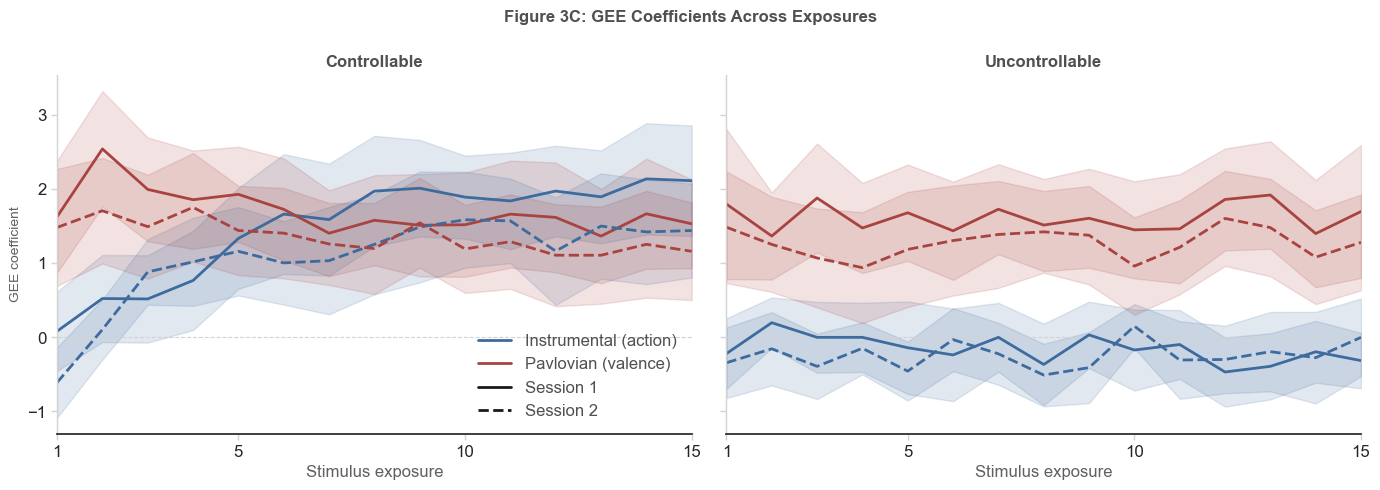

Saved fig03C


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.patch.set_facecolor('white')

for col, (ax, cond) in enumerate(zip(axes, conds)):
    ax.axhline(0, color=axiscolor, lw=0.8, ls='--')
    sub = gee_df[gee_df['controllability']==cond]
    for sess, ls in zip(sessions, ['-','--']):
        s = sub[sub['session']==sess].sort_values('exposure')
        if len(s)==0: continue
        ax.plot(s['exposure'], s['action_coef'],  color=COLOR_CON, lw=2, ls=ls)
        ax.fill_between(s['exposure'], s['action_lb'],  s['action_ub'],
                        color=COLOR_CON, alpha=0.15)
        ax.plot(s['exposure'], s['valence_coef'], color=COLOR_UNC, lw=2, ls=ls)
        ax.fill_between(s['exposure'], s['valence_lb'], s['valence_ub'],
                        color=COLOR_UNC, alpha=0.15)
    ax.set_xlim(1, 15)
    ax.set_xticks([1, 5, 10, 15])
    ax.set_xlabel('Stimulus exposure', color=tickcolor, fontsize=12)
    ax.set_title(cond.capitalize(), color=labelcolor, fontsize=12, fontweight='bold')
    ax.spines['left'].set(linewidth=1, color=axiscolor)
    ax.tick_params(color=axiscolor, length=4, width=1)
    sns.despine(ax=ax, left=False, right=True, top=True, bottom=False)
    if col == 0:
        ax.set_ylabel('GEE coefficient', color=tickcolor, fontsize=10)
        legend_gee = [
            Line2D([0],[0], color=COLOR_CON, lw=2, label='Instrumental (action)'),
            Line2D([0],[0], color=COLOR_UNC, lw=2, label='Pavlovian (valence)'),
            Line2D([0],[0], color='k', lw=2, ls='-',  label='Session 1'),
            Line2D([0],[0], color='k', lw=2, ls='--', label='Session 2'),
        ]
        ax.legend(handles=legend_gee, frameon=False, fontsize=12,
                  labelcolor=labelcolor, loc='lower right')
    else:
        ax.tick_params(labelleft=False)

plt.suptitle('Figure 3C: GEE Coefficients Across Exposures', color=labelcolor, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig03C_gee.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig03C_gee.pdf'), bbox_inches='tight')
plt.show()
print('Saved fig03C')

## 13 — Compute ICC for Figure 4A and 4B

In [71]:
# Compute subject-level measures
records = []
for (subj, sess, cond), grp in data.groupby(['subject','session','controllability']):
    acc      = grp.groupby('robot_type')['accuracy'].mean()
    overall  = grp['accuracy'].mean()
    go_bias  = (grp[grp['action']=='go']['accuracy'].mean() -
                grp[grp['action']=='no-go']['accuracy'].mean())
    pav_bias = (grp[grp['congruence']=='c']['accuracy'].mean() -
                grp[grp['congruence']=='i']['accuracy'].mean())
    approach  = acc.get('gw',np.nan) - acc.get('ngw',np.nan)
    avoidance = acc.get('ngal',np.nan) - acc.get('gal',np.nan)
    if cond == 'controllable':
        sub_fb = grp[grp['prev_sham'].isin([0.0,1.0])]
        fb = (sub_fb[sub_fb['prev_sham']==0]['accuracy'].mean() -
              sub_fb[sub_fb['prev_sham']==1]['accuracy'].mean()) if len(sub_fb)>0 else np.nan
    else:
        fb = np.nan
    records.append({'subject':subj,'session':sess,'controllability':cond,
                    'accuracy':overall,'go_bias':go_bias,'pav_bias':pav_bias,
                    'approach':approach,'avoidance':avoidance,'feedback':fb})
mf = pd.DataFrame(records)

# Compute LPM coefficients per subject
lpm_records = []
for (subj, sess, cond), grp in data.groupby(['subject','session','controllability']):
    if len(grp) < 4: continue
    try:
        X      = sm.add_constant(grp[['valence_bin','action_bin']])
        model  = sm.OLS(grp['choice'], X).fit()
        lpm_records.append({'subject':subj,'session':sess,'controllability':cond,
                            'action_coef': model.params['action_bin'],
                            'valence_coef':model.params['valence_bin']})
    except: continue
lpm_df = pd.DataFrame(lpm_records)
lpm_df['delta'] = lpm_df['valence_coef'] - lpm_df['action_coef']

# ICC Panel A
measures_A = [
    ('accuracy', 'Overall\naccuracy'),
    ('go_bias',  'Go\nbias'),
    ('pav_bias', 'Pavlovian\nbias'),
    ('approach', 'Approach\nbias'),
    ('avoidance','Avoidance\nbias'),
    ('feedback', 'Feedback\nsensitivity'),
]

icc_A = {}
print('ICC Panel A:')
for col, label in measures_A:
    icc_A[col] = {}
    for cond in ['controllable','uncontrollable']:
        sub    = mf[mf['controllability']==cond]
        s1     = sub[sub['session']==1].set_index('subject')[col]
        s2     = sub[sub['session']==2].set_index('subject')[col]
        common = s1.index.intersection(s2.index)
        icc_A[col][cond] = compute_icc(s1.loc[common].values, s2.loc[common].values) if len(common)>=3 else (np.nan,np.nan,np.nan)
        r, lb, ub = icc_A[col][cond]
        print(f'  {col:12s} {cond[:3]}: ICC={r:.3f} [{lb:.3f}, {ub:.3f}]')
    # Con-Uncon diff
    s1d = mf[(mf['session']==1)&(mf['controllability']=='controllable')].set_index('subject')[col] - \
          mf[(mf['session']==1)&(mf['controllability']=='uncontrollable')].set_index('subject')[col]
    s2d = mf[(mf['session']==2)&(mf['controllability']=='controllable')].set_index('subject')[col] - \
          mf[(mf['session']==2)&(mf['controllability']=='uncontrollable')].set_index('subject')[col]
    common = s1d.dropna().index.intersection(s2d.dropna().index)
    icc_A[col]['diff'] = compute_icc(s1d.loc[common].values, s2d.loc[common].values) if len(common)>=3 else (np.nan,np.nan,np.nan)
    r, lb, ub = icc_A[col]['diff']
    print(f'  {col:12s} diff: ICC={r:.3f} [{lb:.3f}, {ub:.3f}]')

# ICC Panel B
measures_B = [
    ('action_coef',  'Instrumental\ncoefficient'),
    ('valence_coef', 'Pavlovian\ncoefficient'),
    ('delta',        'Delta\n(Pav−Inst)'),
]
icc_B = {}
print('\nICC Panel B:')
for col, label in measures_B:
    icc_B[col] = {}
    for cond in ['controllable','uncontrollable']:
        sub    = lpm_df[lpm_df['controllability']==cond]
        s1     = sub[sub['session']==1].set_index('subject')[col]
        s2     = sub[sub['session']==2].set_index('subject')[col]
        common = s1.index.intersection(s2.index)
        icc_B[col][cond] = compute_icc(s1.loc[common].values, s2.loc[common].values) if len(common)>=3 else (np.nan,np.nan,np.nan)
        r, lb, ub = icc_B[col][cond]
        print(f'  {col:12s} {cond[:3]}: ICC={r:.3f} [{lb:.3f}, {ub:.3f}]')

ICC Panel A:
  accuracy     con: ICC=0.869 [0.720, 0.940]
  accuracy     unc: ICC=0.180 [-0.230, 0.540]
  accuracy     diff: ICC=0.845 [0.670, 0.930]
  go_bias      con: ICC=0.502 [0.130, 0.750]
  go_bias      unc: ICC=0.608 [0.280, 0.810]
  go_bias      diff: ICC=0.219 [-0.190, 0.570]
  pav_bias     con: ICC=0.576 [0.230, 0.790]
  pav_bias     unc: ICC=0.660 [0.360, 0.840]
  pav_bias     diff: ICC=-0.021 [-0.410, 0.380]
  approach     con: ICC=0.588 [0.250, 0.800]
  approach     unc: ICC=0.527 [0.170, 0.760]
  approach     diff: ICC=0.111 [-0.300, 0.490]
  avoidance    con: ICC=0.511 [0.140, 0.750]
  avoidance    unc: ICC=0.723 [0.460, 0.870]
  avoidance    diff: ICC=0.124 [-0.290, 0.500]
  feedback     con: ICC=-0.095 [-0.470, 0.310]
  feedback     unc: ICC=nan [nan, nan]
  feedback     diff: ICC=nan [nan, nan]

ICC Panel B:
  action_coef  con: ICC=0.869 [0.720, 0.940]
  action_coef  unc: ICC=0.180 [-0.230, 0.540]
  valence_coef con: ICC=0.576 [0.230, 0.790]
  valence_coef unc: ICC=0

## 14 — Figure 4A: ICC — Behavioural Measures

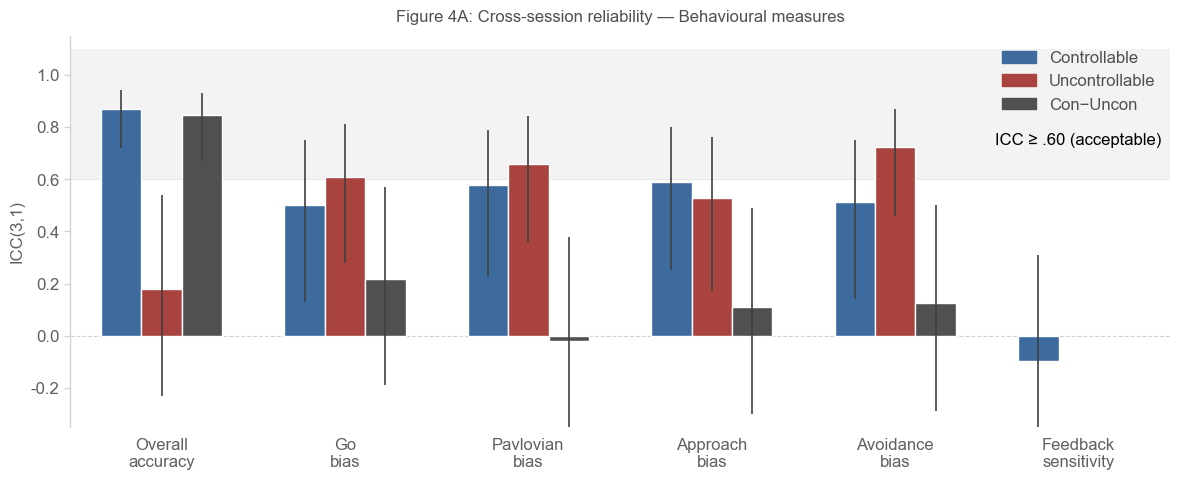

Saved fig04A


In [72]:
def plot_icc(ax, icc_data, measures_list, title, show_diff=True, text_y=0.72):
    n, width = len(measures_list), 0.22
    x = np.arange(n)
    ax.axhspan(0.60, 1.10, color=axiscolor, alpha=0.25, lw=0, zorder=1)
    ax.axhline(0,    color=axiscolor, lw=0.8, ls='--')
    ax.axhline(0.60, color=axiscolor, lw=0.8, ls='-', alpha=0.5)
    configs = [('controllable', COLOR_CON, -width), ('uncontrollable', COLOR_UNC, 0.0)]
    if show_diff: configs.append(('diff', COLOR_DIFF, width))
    for cond_key, color, off in configs:
        for i, (col, _) in enumerate(measures_list):
            r, lb, ub = icc_data[col].get(cond_key, (np.nan,np.nan,np.nan))
            if np.isnan(float(r)): continue
            ax.bar(x[i]+off, float(r), width=width, color=color, zorder=3)
            if not np.isnan(float(lb)):
                ax.errorbar(x[i]+off, float(r),
                            yerr=[[float(r)-float(lb)],[float(ub)-float(r)]],
                            fmt='none', color='#404040', elinewidth=1.2, capsize=0, zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _,lbl in measures_list], color=tickcolor, fontsize=12)
    ax.set_ylabel('ICC(3,1)', color=tickcolor, fontsize=12)
    ax.set_ylim(-0.35, 1.15)
    ax.set_xlim(-0.5, n-0.5)
    ax.set_yticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels([f'{v:.1f}' for v in [-0.2,0,0.2,0.4,0.6,0.8,1.0]], color=tickcolor)
    ax.spines['left'].set(linewidth=1, color=axiscolor)
    ax.tick_params(color=axiscolor, length=4, width=1, bottom=False)
    sns.despine(ax=ax, left=False, right=True, top=True, bottom=True)
    ax.set_title(title, color=labelcolor, fontsize=12, pad=10)
    ax.text(n-0.55, text_y, 'ICC ≥ .60 (acceptable)',
            ha='right', va='bottom', color='black', fontsize=12)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('white')
plot_icc(ax, icc_A, measures_A, 'Figure 4A: Cross-session reliability — Behavioural measures', show_diff=True)
legend_handles = [
    Patch(color=COLOR_CON,  label='Controllable'),
    Patch(color=COLOR_UNC,  label='Uncontrollable'),
    Patch(color=COLOR_DIFF, label='Con−Uncon'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=12,
          labelcolor=labelcolor, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig04A_icc_behavioural.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig04A_icc_behavioural.pdf'), bbox_inches='tight')
plt.show()
print('Saved fig04A')

## 15 — Figure 4B: ICC — LPM Regression Coefficients